In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import zipfile

zip_path = "/content/drive/MyDrive/archive.zip"
extract_path = "/content"

if not os.path.exists("/content/chest_xray/train"):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

print("Dataset ready!")

Dataset ready!


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_data = tf.keras.utils.image_dataset_from_directory(
    "/content/chest_xray/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=42
)

val_data = tf.keras.utils.image_dataset_from_directory(
    "/content/chest_xray/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_data = tf.keras.utils.image_dataset_from_directory(
    "/content/chest_xray/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Classes:", train_data.class_names)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']


In [ ]:
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1)
])

base_model = tf.keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model2 = tf.keras.Model(inputs, outputs)

model2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Second model created successfully!")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Second model created successfully!


In [ ]:
model1 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model1.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history1 = model1.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 584s 4s/step - accuracy: 0.8691 - loss: 0.3104 - val_accuracy: 0.8125 - val_loss: 0.4537
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 625s 4s/step - accuracy: 0.9503 - loss: 0.1421 - val_accuracy: 0.7500 - val_loss: 0.5393
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 582s 4s/step - accuracy: 0.9582 - loss: 0.1076 - val_accuracy: 0.8750 - val_loss: 0.2555
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 617s 4s/step - accuracy: 0.9643 - loss: 0.0965 - val_accuracy: 0.7500 - val_loss: 0.6547
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 631s 4s/step - accuracy: 0.9711 - loss: 0.0771 - val_accuracy: 0.9375 - val_loss: 0.1665


In [ ]:

history2 = model2.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 466s 3s/step - accuracy: 0.8414 - loss: 0.3390 - val_accuracy: 0.8750 - val_loss: 0.4194
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 492s 3s/step - accuracy: 0.9080 - loss: 0.2180 - val_accuracy: 0.8750 - val_loss: 0.3394
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 444s 3s/step - accuracy: 0.9260 - loss: 0.1889 - val_accuracy: 0.8750 - val_loss: 0.3161
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 430s 3s/step - accuracy: 0.9304 - loss: 0.1705 - val_accuracy: 0.8750 - val_loss: 0.2159
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 443s 3s/step - accuracy: 0.9388 - loss: 0.1556 - val_accuracy: 0.8750 - val_loss: 0.2104


In [ ]:

# Evaluate both models on the same test dataset

test_loss1, test_acc1 = model1.evaluate(test_data, verbose=1)
test_loss2, test_acc2 = model2.evaluate(test_data, verbose=1)

print("\nFinal Test Results")
print("------------------")
print(f"Normal CNN Test Accuracy: {test_acc1 * 100:.2f}%")
print(f"EfficientNetB0 Test Accuracy: {test_acc2 * 100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 983ms/step - accuracy: 0.7580 - loss: 0.9560
20/20 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.8253 - loss: 0.3837

Final Test Results
------------------
Normal CNN Test Accuracy: 75.80%
EfficientNetB0 Test Accuracy: 82.53%


20/20 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step


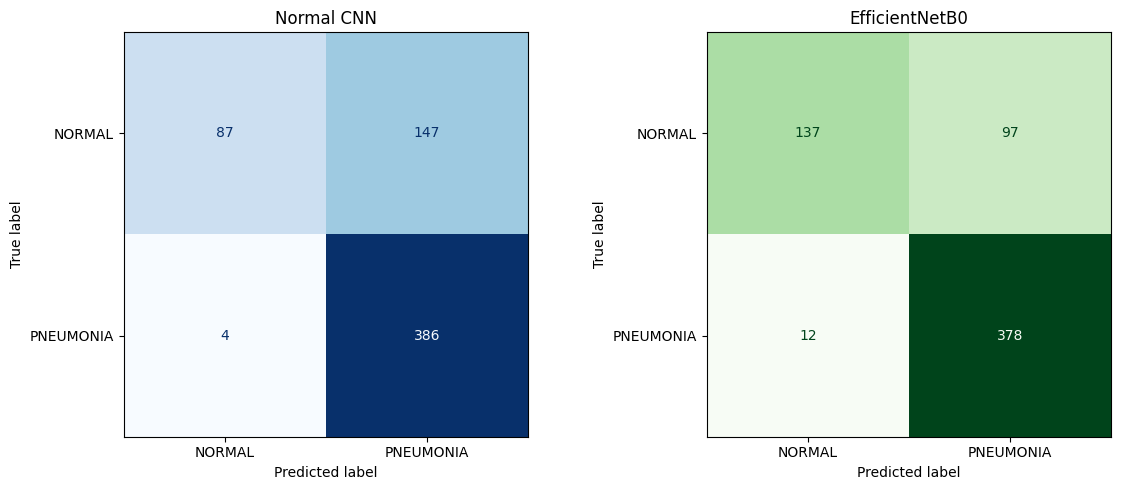

NORMAL CNN CLASSIFICATION REPORT
              precision    recall  f1-score   support

      NORMAL       0.96      0.37      0.54       234
   PNEUMONIA       0.72      0.99      0.84       390

    accuracy                           0.76       624
   macro avg       0.84      0.68      0.69       624
weighted avg       0.81      0.76      0.72       624

EFFICIENTNETB0 CLASSIFICATION REPORT
              precision    recall  f1-score   support

      NORMAL       0.92      0.59      0.72       234
   PNEUMONIA       0.80      0.97      0.87       390

    accuracy                           0.83       624
   macro avg       0.86      0.78      0.79       624
weighted avg       0.84      0.83      0.81       624



In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Get the true labels from the test dataset
y_true = np.concatenate([labels.numpy() for images, labels in test_data])

# Get predictions from both models
pred1 = model1.predict(test_data, verbose=1).ravel()
pred2 = model2.predict(test_data, verbose=1).ravel()

# Convert probabilities into class labels: 0 = NORMAL, 1 = PNEUMONIA
y_pred1 = (pred1 >= 0.5).astype(int)
y_pred2 = (pred2 >= 0.5).astype(int)

# Display confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred1),
    display_labels=test_data.class_names
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Normal CNN")

ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred2),
    display_labels=test_data.class_names
).plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title("EfficientNetB0")

plt.tight_layout()
plt.savefig("confusion_matrices_approach2.png", dpi=150, bbox_inches="tight")
plt.show()

print("NORMAL CNN CLASSIFICATION REPORT")
print(classification_report(
    y_true, y_pred1,
    target_names=test_data.class_names,
    zero_division=0
))

print("EFFICIENTNETB0 CLASSIFICATION REPORT")
print(classification_report(
    y_true, y_pred2,
    target_names=test_data.class_names,
    zero_division=0
))

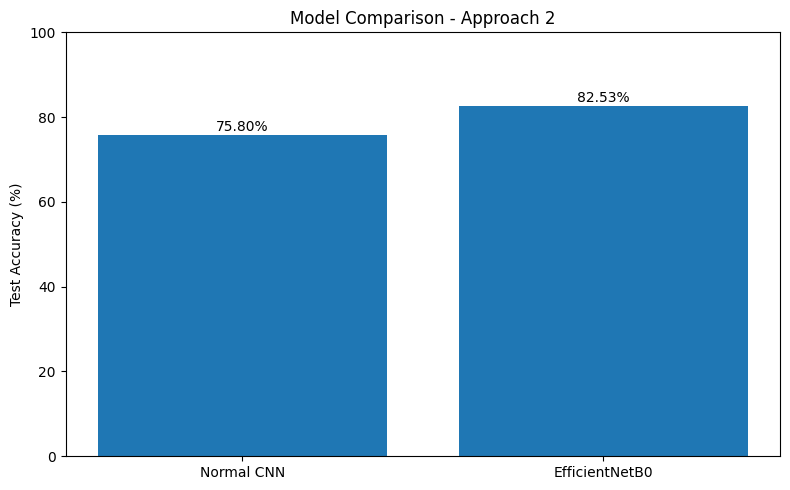

Comparison graph saved successfully!


In [ ]:

import matplotlib.pyplot as plt

models = ["Normal CNN", "EfficientNetB0"]
accuracies = [test_acc1 * 100, test_acc2 * 100]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies)

plt.title("Model Comparison - Approach 2")
plt.ylabel("Test Accuracy (%)")
plt.ylim(0, 100)

for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.savefig("model_comparison_approach2.png", dpi=150, bbox_inches="tight")
plt.show()

print("Comparison graph saved successfully!")

In [ ]:


model1.save("/content/normal_cnn_approach2.keras")
model2.save("/content/efficientnetb0_approach2.keras")

print("Both models saved successfully!")

Both models saved successfully!


In [ ]:

from google.colab import files

uploaded = files.upload()

Saving 1000110594.jpg to 1000110594.jpg


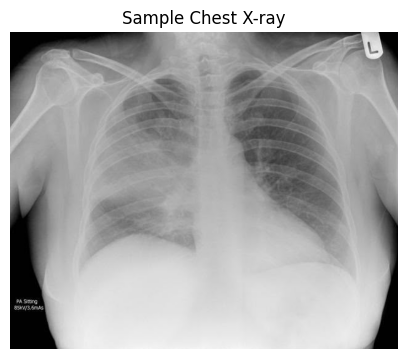

Normal CNN: PNEUMONIA (model score: 61.42%)
EfficientNetB0: PNEUMONIA (model score: 51.14%)


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Get the uploaded image filename
image_path = next(iter(uploaded.keys()))

# Load and resize the image
img = Image.open(image_path).convert("RGB")
img_resized = img.resize((224, 224))

# Convert image to an array
img_array = np.array(img_resized, dtype=np.float32)
img_array = np.expand_dims(img_array, axis=0)

# Predict using both models
# Model 1 includes Rescaling(1./255) inside the model
prediction1 = model1.predict(img_array, verbose=0)[0][0]

# EfficientNetB0 model uses its built-in preprocessing
prediction2 = model2.predict(img_array, verbose=0)[0][0]

# Display the sample image
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title("Sample Chest X-ray")
plt.show()

# Display predictions
for name, prediction in [
    ("Normal CNN", prediction1),
    ("EfficientNetB0", prediction2)
]:
    label = "PNEUMONIA" if prediction >= 0.5 else "NORMAL"
    confidence = prediction if prediction >= 0.5 else 1 - prediction

    print(f"{name}: {label} (model score: {confidence * 100:.2f}%)")